## 1. Importing Libraries

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyspark.sql import functions as F

## 2. Loading the Dataset

In [0]:
df_spark = spark.table("municipal_revenue")

print(f"Number of rows: {df_spark.count():,}")
print(f"Number of columns: {len(df_spark.columns)}")

Number of rows: 600,000
Number of columns: 13


## 3. Inspecting the Dataset

In [0]:
display(df_spark.limit(10))

customer_id,province,municipality,customer_type,property_type,service_type,billing_date,billing_amount,payment_amount,payment_method,payment_status,outstanding_balance,days_overdue
CUST009376,Limpopo,Municipality_C,Residential,Apartment,Water,2024-01-01,839.47,625.5,Card,Partial,213.97,13
CUST009377,Limpopo,Municipality_C,Residential,Apartment,Property Rates,2024-02-01,1342.1,389.58,Card,Partial,952.52,58
CUST009378,Gauteng,Municipality_B,Residential,Apartment,Electricity,2024-03-01,835.26,835.26,EFT,Paid,0.0,0
CUST009379,KwaZulu-Natal,Municipality_H,Residential,Apartment,Water,2024-04-01,964.0,0.0,None,Unpaid,964.0,265
CUST009380,Limpopo,Municipality_D,Residential,House,Electricity,2024-05-01,1112.43,1112.43,Cash,Paid,0.0,0
CUST009381,Limpopo,Municipality_D,Residential,House,Electricity,2024-06-01,1446.16,1446.16,Cash,Paid,0.0,0
CUST009382,Limpopo,Municipality_D,Residential,House,Electricity,2024-07-01,980.67,980.67,EFT,Paid,0.0,0
CUST009383,Limpopo,Municipality_C,Residential,Apartment,Water,2024-08-01,563.61,563.61,EFT,Paid,0.0,0
CUST009384,Gauteng,Municipality_B,Business,Apartment,Electricity,2024-09-01,4441.8,0.0,None,Unpaid,4441.8,211
CUST009385,Gauteng,Municipality_A,Residential,House,Water,2024-10-01,812.38,812.38,Card,Paid,0.0,0


## 4. Converting the table to Pandas for EDA (Exploratory Data Analysis)

In [0]:
df = df_spark.toPandas()

In [0]:
df.head()

,customer_id,province,municipality,customer_type,property_type,service_type,billing_date,billing_amount,payment_amount,payment_method,payment_status,outstanding_balance,days_overdue
0,CUST009376,Limpopo,Municipality_C,Residential,Apartment,Water,2024-01-01,839.47,625.50,Card,Partial,213.97,13
1,CUST009377,Limpopo,Municipality_C,Residential,Apartment,Property Rates,2024-02-01,1342.10,389.58,Card,Partial,952.52,58
2,CUST009378,Gauteng,Municipality_B,Residential,Apartment,Electricity,2024-03-01,835.26,835.26,EFT,Paid,0.00,0
3,CUST009379,KwaZulu-Natal,Municipality_H,Residential,Apartment,Water,2024-04-01,964.00,0.00,None,Unpaid,964.00,265
4,CUST009380,Limpopo,Municipality_D,Residential,House,Electricity,2024-05-01,1112.43,1112.43,Cash,Paid,0.00,0


In [0]:
df.shape

(600000, 13)

## 5. Understand the Dataset

In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   customer_id          600000 non-null  object 
 1   province             600000 non-null  object 
 2   municipality         600000 non-null  object 
 3   customer_type        600000 non-null  object 
 4   property_type        600000 non-null  object 
 5   service_type         600000 non-null  object 
 6   billing_date         600000 non-null  object 
 7   billing_amount       600000 non-null  float64
 8   payment_amount       600000 non-null  float64
 9   payment_method       600000 non-null  object 
 10  payment_status       600000 non-null  object 
 11  outstanding_balance  600000 non-null  float64
 12  days_overdue         600000 non-null  int32  
dtypes: float64(3), int32(1), object(9)
memory usage: 57.2+ MB


In [0]:
df.describe(include="all")

,customer_id,province,municipality,customer_type,property_type,service_type,billing_date,billing_amount,payment_amount,payment_method,payment_status,outstanding_balance,days_overdue
count,600000,600000,600000,600000,600000,600000,600000,600000.000000,600000.000000,600000,600000,600000.000000,600000.000000
unique,25000,4,8,2,3,4,24,NaN,NaN,5,3,NaN,NaN
top,CUST009376,Limpopo,Municipality_C,Residential,House,Water,2024-01-01,NaN,NaN,EFT,Paid,NaN,NaN
freq,24,215448,107808,492240,392760,251634,25000,NaN,NaN,261132,408143,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1237.276277,1019.986317,NaN,NaN,217.289960,18.616275
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,968.354725,915.751415,NaN,NaN,479.044904,41.075999
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,225.010000,0.000000,NaN,NaN,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,653.707500,430.920000,NaN,NaN,0.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,935.990000,802.200000,NaN,NaN,0.000000,0.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1430.012500,1254.300000,NaN,NaN,263.630000,22.000000


In [0]:
df.dtypes

customer_id             object
province                object
municipality            object
customer_type           object
property_type           object
service_type            object
billing_date            object
billing_amount         float64
payment_amount         float64
payment_method          object
payment_status          object
outstanding_balance    float64
days_overdue             int32
dtype: object

## 6. Checking for missing values (Null values)

In [0]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing

customer_id            0
province               0
municipality           0
customer_type          0
property_type          0
service_type           0
billing_date           0
billing_amount         0
payment_amount         0
payment_method         0
payment_status         0
outstanding_balance    0
days_overdue           0
dtype: int64

The are no missing values in this dataset

In [0]:
missing_pct = (
    df.isnull()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

missing_pct

customer_id            0.0
province               0.0
municipality           0.0
customer_type          0.0
property_type          0.0
service_type           0.0
billing_date           0.0
billing_amount         0.0
payment_amount         0.0
payment_method         0.0
payment_status         0.0
outstanding_balance    0.0
days_overdue           0.0
dtype: float64

0% missing values in the dataset

## 7. Checking for Duplicates

In [0]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate records: {duplicate_count:,}" )

Duplicate records: 0


Hence, there are a total of 0 duplicated rows

## 8. Checking Unique Values for Categorcal Variables

This is an important EDA step because we want to understand what we're actually working with before producing visualizations.

In [0]:
categorical_columns = [
    "province",
    "municipality",
    "customer_type",
    "property_type",
    "service_type",
    "payment_method",
    "payment_status"
]

for column in categorical_columns:
    print(f"\n --- {column.upper()} ---")
    print(df[column].value_counts())


 --- PROVINCE ---
province
Limpopo          215448
Gauteng          206688
Mpumalanga       132552
KwaZulu-Natal     45312
Name: count, dtype: int64

 --- MUNICIPALITY ---
municipality
Municipality_C    107808
Municipality_D    107640
Municipality_B    104424
Municipality_A    102264
Municipality_E     66528
Municipality_F     66024
Municipality_H     23136
Municipality_G     22176
Name: count, dtype: int64

 --- CUSTOMER_TYPE ---
customer_type
Residential    492240
Business       107760
Name: count, dtype: int64

 --- PROPERTY_TYPE ---
property_type
House         392760
Apartment     176040
Commercial     31200
Name: count, dtype: int64

 --- SERVICE_TYPE ---
service_type
Water             251634
Electricity       240478
Waste              97218
Property Rates     10670
Name: count, dtype: int64

 --- PAYMENT_METHOD ---
payment_method
EFT            261132
Card           239868
Cash            71955
None            19086
Debit Order      7959
Name: count, dtype: int64

 --- PAYMENT_S

## 9. Validating financial variables

Checking whether there are strange values

In [0]:
financial_columns = [
    "billing_amount",
    "payment_amount",
    "outstanding_balance"
]

df[financial_columns].describe()

,billing_amount,payment_amount,outstanding_balance
count,600000.000000,600000.000000,600000.000000
mean,1237.276277,1019.986317,217.289960
std,968.354725,915.751415,479.044904
min,225.010000,0.000000,0.000000
25%,653.707500,430.920000,0.000000
50%,935.990000,802.200000,0.000000
75%,1430.012500,1254.300000,263.630000
max,5249.980000,5249.980000,5236.420000


In [0]:
for column in financial_columns:
    print(
        column,
        "negative_values",
        (df[column] < 0).sum()
    )

billing_amount negative_values 0
payment_amount negative_values 0
outstanding_balance negative_values 0


Therefore, there are no negative billing, payment, or outstanding balances

## 10. Validating our financial logic

Outstanding Balance = Billing Amount - Payment Amount

Let's verify that

In [0]:
df.columns

Index(['customer_id', 'province', 'municipality', 'customer_type',
       'property_type', 'service_type', 'billing_date', 'billing_amount',
       'payment_amount', 'payment_method', 'payment_status',
       'outstanding_balance', 'days_overdue'],
      dtype='object')

In [0]:
df["calculated_outstanding"] = (
    df["billing_amount"] - df["payment_amount"]
)

difference = (
    df["calculated_outstanding"] - 
    df["outstanding_balance"]
).abs()

print(
    "Records with incorrect outstanding balance:",
    (difference > 0.01).sum()
)

Records with incorrect outstanding balance: 0


## 11. Revenue Overview

Now we start doing actual EDA

In [0]:
total_billed = df["billing_amount"].sum()
total_collected = df["payment_amount"].sum()
total_outstanding = df["outstanding_balance"].sum()

collection_rate = (
    (total_collected / total_billed) * 100
)

print(f"Total billed:       R{total_billed:,.2f}")
print(f"Total collected:    R{total_collected:,.2f}")
print(f"Total outstanding:  R{total_outstanding:,.2f}")
print(f"Collection rate:    {collection_rate:.2f}%")

Total billed:       R742,365,766.48
Total collected:    R611,991,790.37
Total outstanding:  R130,373,976.11
Collection rate:    82.44%


## 12. Revenue by service

In [0]:
service_summary = (
    df.groupby("service_type")
      .agg(
          total_billed=("billing_amount", "sum"),
          total_collected=("payment_amount", "sum"),
          total_outstanding=("outstanding_balance", "sum")
      )
)

service_summary["collection_rate"] = (
    service_summary["total_collected"]
    / service_summary["total_billed"]
    * 100
)

service_summary.sort_values(
    "total_billed",
    ascending=False
)

,total_billed,total_collected,total_outstanding,collection_rate
service_type,,,,
Electricity,4.142788e+08,3.412554e+08,73023411.34,82.373365
Water,2.627289e+08,2.168713e+08,45857655.50,82.545638
Waste,5.045906e+07,4.155497e+07,8904093.68,82.353826
Property Rates,1.489899e+07,1.231018e+07,2588815.59,82.624224


## Visualizing Billing Amount by Service

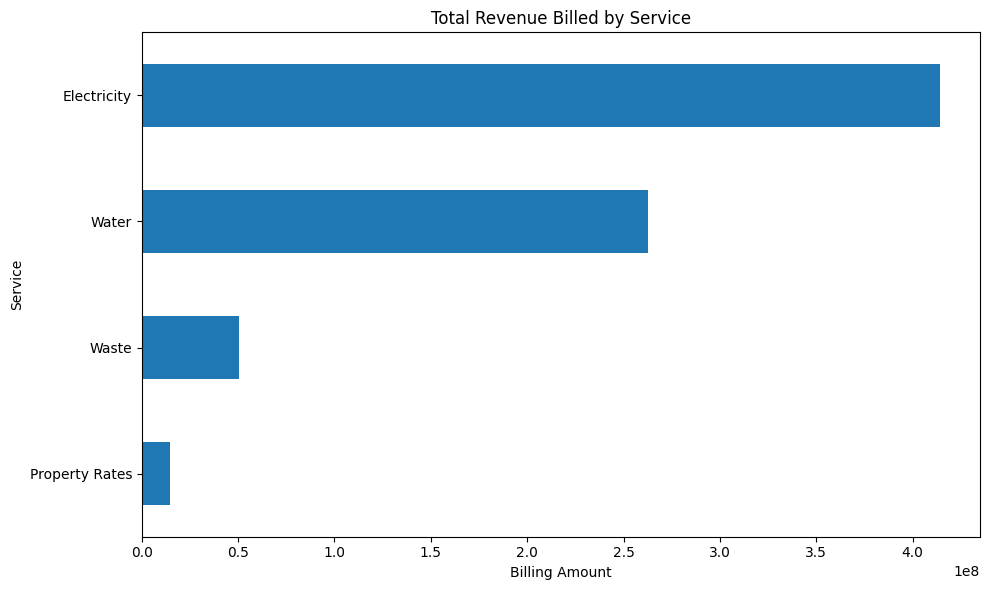

In [0]:
service_summary["total_billed"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Total Revenue Billed by Service")
plt.xlabel("Billing Amount")
plt.ylabel("Service")
plt.tight_layout()
plt.show()

Electricity is the service that generates the most billing amount

## 13. Collection performance by municipality (Revenue by Municipality)

In [0]:
municipality_summary = (
    df.groupby("municipality")
      .agg(
          total_billed=("billing_amount", "sum"),
          total_collected=("payment_amount", "sum"),
          outstanding=("outstanding_balance", "sum")
      )
)

municipality_summary["collection_rate"] = (
    municipality_summary["total_collected"]
    / municipality_summary["total_billed"]
    * 100
)

municipality_summary.sort_values(
    "collection_rate"
)

,total_billed,total_collected,outstanding,collection_rate
municipality,,,,
Municipality_D,1.303135e+08,1.071789e+08,23134633.43,82.246941
Municipality_H,2.834862e+07,2.332745e+07,5021172.54,82.287770
Municipality_C,1.340897e+08,1.104784e+08,23611374.48,82.391365
Municipality_E,8.305455e+07,6.845242e+07,14602130.69,82.418626
Municipality_F,8.053743e+07,6.638194e+07,14155489.91,82.423713
Municipality_B,1.297053e+08,1.069702e+08,22735062.30,82.471753
Municipality_A,1.284224e+08,1.060351e+08,22387338.71,82.567420
Municipality_G,2.789423e+07,2.316745e+07,4726774.05,83.054651


## Visualizing Billing Amount by Municipality

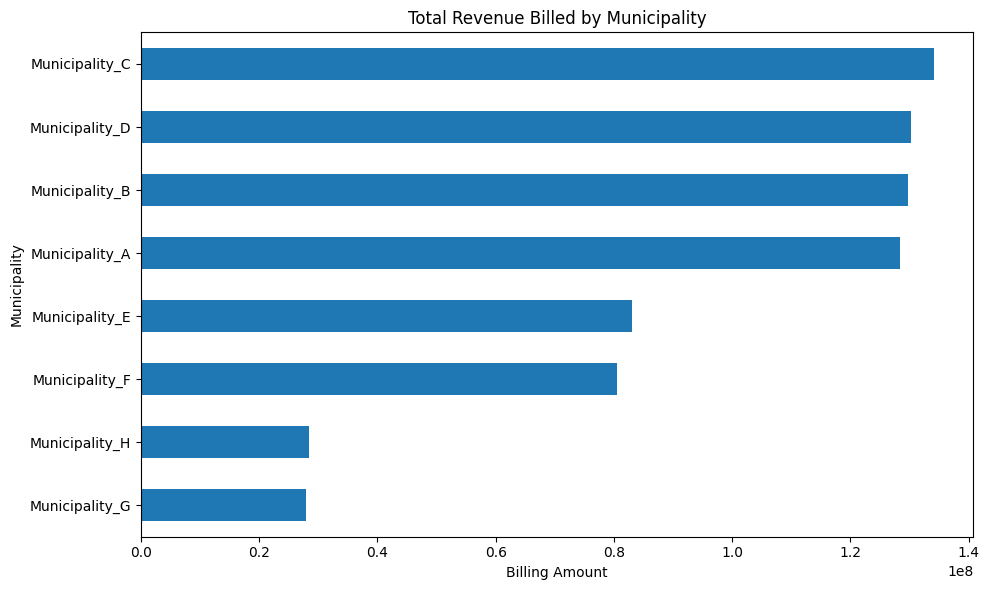

In [0]:
municipality_summary["total_billed"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Total Revenue Billed by Municipality")
plt.xlabel("Billing Amount")
plt.ylabel("Municipality")
plt.tight_layout()
plt.show()

Municipality_C generated the highest billing amount 

This is one of the most important analyses in the project.

We're looking for municipalities with:

high revenue + low collection rate

because those are potentially high-priority areas.

## 14. Payment-status Analysis

In [0]:
status_summary = (
    df.groupby("payment_status")
      .agg(
          accounts=("customer_id", "count"),
          billed=("billing_amount", "sum"),
          collected=("payment_amount", "sum"),
          outstanding=("outstanding_balance", "sum")
    )
)

status_summary

,accounts,billed,collected,outstanding
payment_status,,,,
Paid,408143,5.051611e+08,5.051611e+08,0.000000e+00
Partial,172771,2.137424e+08,1.068307e+08,1.069117e+08
Unpaid,19086,2.346223e+07,0.000000e+00,2.346223e+07


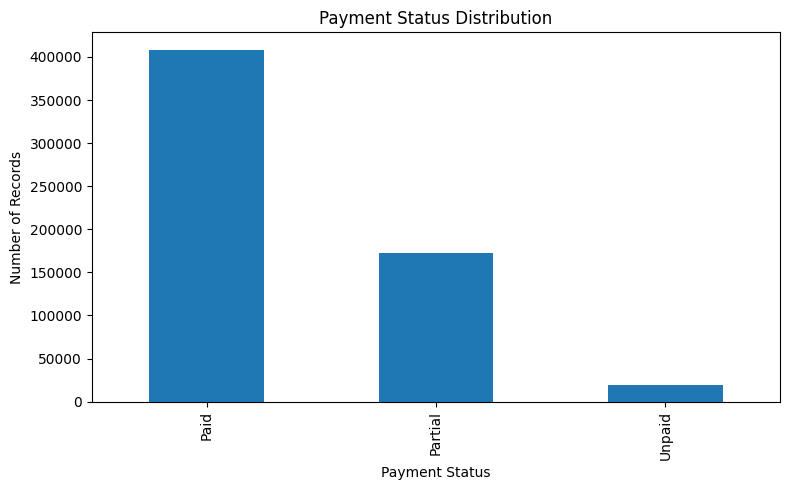

In [0]:
status_counts = df["payment_status"].value_counts()

status_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Payment Status Distribution")
plt.xlabel("Payment Status")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

## 15. Monthly revenue trend

In [0]:
# Converting the date into a datetime format
df["billing_date"] = pd.to_datetime(df["billing_date"])

In [0]:
monthly = (
    df.groupby("billing_date")
      .agg(
          billed=("billing_amount", "sum"),
          collected=("payment_amount", "sum"),
          outstanding=("outstanding_balance", "sum")
    )
)

## Visualizing billed revenue

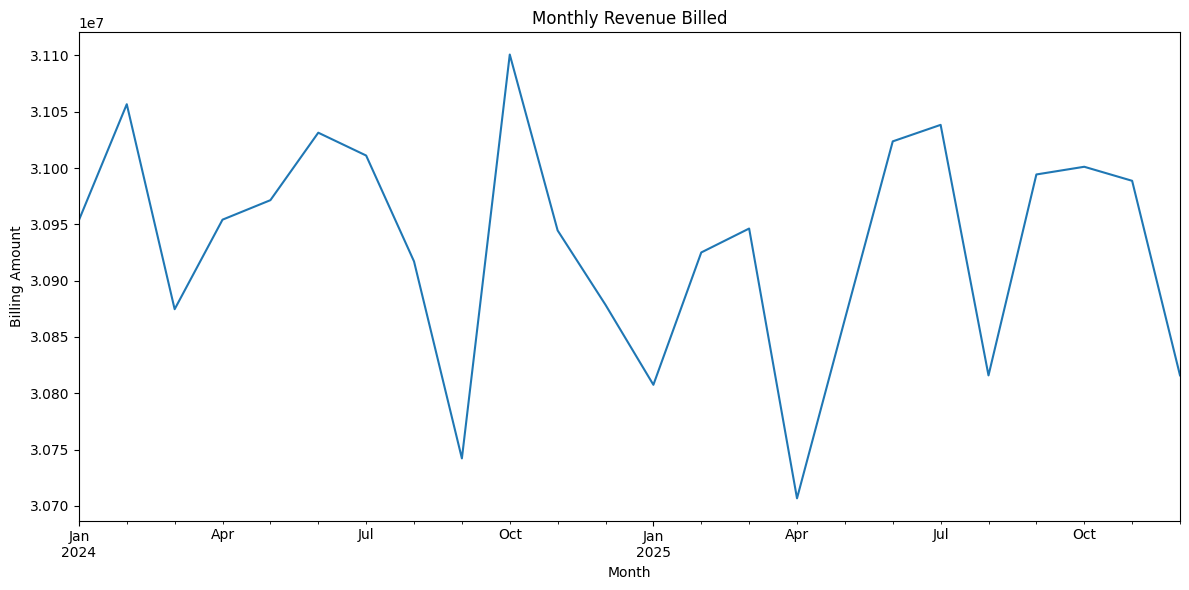

In [0]:
monthly["billed"].plot(
    figsize=(12, 6)
)

plt.title("Monthly Revenue Billed")
plt.xlabel("Month")
plt.ylabel("Billing Amount")
plt.tight_layout()
plt.show()

The highest bill revenue was made during October

## Visualizing collection

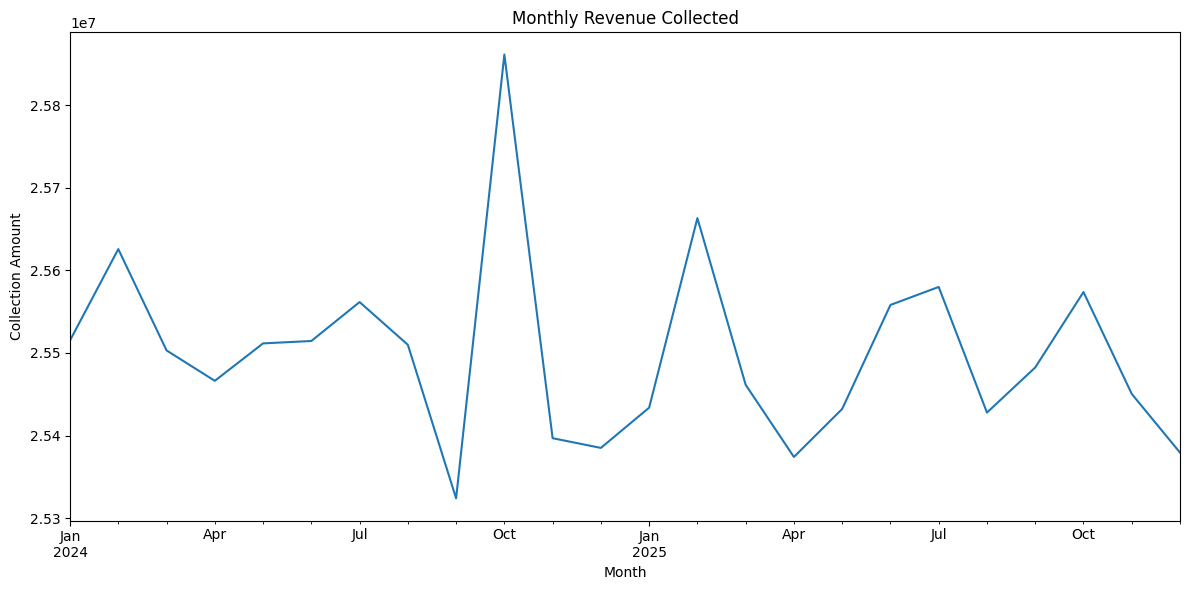

In [0]:
monthly["collected"].plot(
    figsize=(12, 6)
)

plt.title("Monthly Revenue Collected")
plt.xlabel("Month")
plt.ylabel("Collection Amount")
plt.tight_layout()
plt.show()

The highest number of collections were made in October

## 16. Monthly collection rate

In [0]:
monthly["collection_rate"] = (
    monthly["collected"]
    / monthly["billed"]
    * 100
)

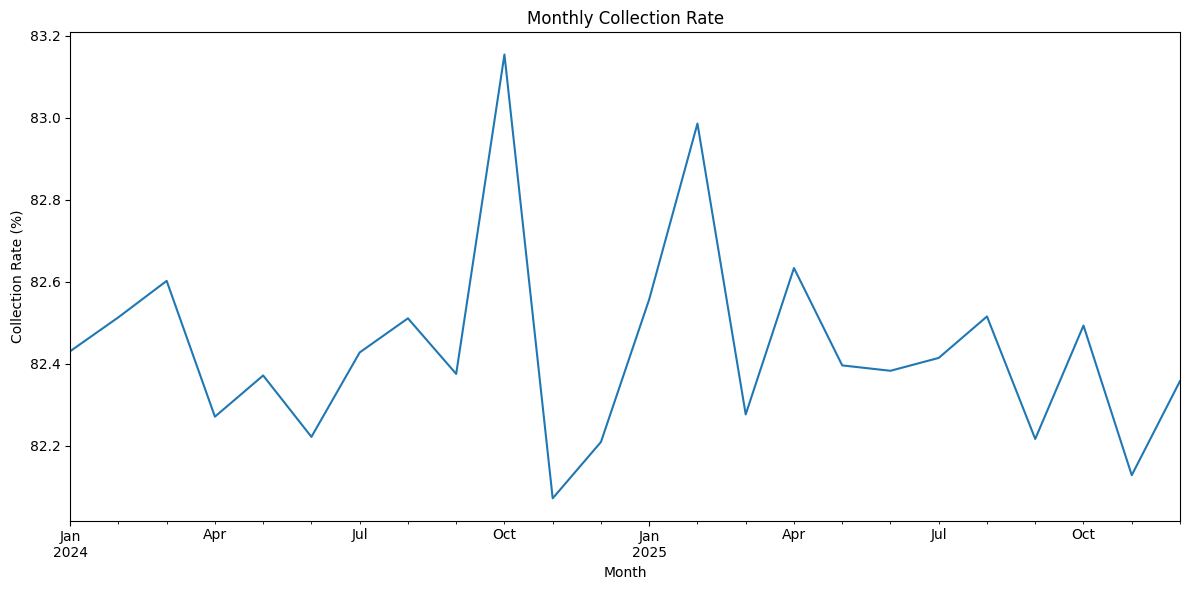

In [0]:
monthly["collection_rate"].plot(
    figsize=(12, 6)
)

plt.title("Monthly Collection Rate")
plt.xlabel("Month")
plt.ylabel("Collection Rate (%)")
plt.tight_layout()
plt.show()

October has the highest collection rate

## 17. Arrears Analysis

In [0]:
# Looking at overdue accounts
arrears = df[df["outstanding_balance"] > 0].copy()

print(f"Accounts with outstanding balances: {len(arrears):,}")

Accounts with outstanding balances: 191,857


In [0]:
arrears["days_overdue"].describe()

count    191857.000000
mean         58.219221
std          54.505980
min           0.000000
25%          25.000000
50%          49.000000
75%          73.000000
max         330.000000
Name: days_overdue, dtype: float64

In [0]:
# arrears per payment_status
arrears.groupby("payment_status")[
    "outstanding_balance"
].sum()

payment_status
Partial    1.069117e+08
Unpaid     2.346223e+07
Name: outstanding_balance, dtype: float64

## 18. Identify high-value outstanding accounts

We're beginning to answer:

Who represents the greatest outstanding revenue exposure?

In [0]:
top_debtors = (
    df.groupby("customer_id")
      .agg(
          total_billed=("billing_amount", "sum"),
          total_paid=("payment_amount", "sum"),
          total_outstanding=("outstanding_balance", "sum"),
          average_days_overdue=("days_overdue", "mean")
      )
      .sort_values(
          "total_outstanding",
          ascending=False
      )
)

top_debtors.head(20)

,total_billed,total_paid,total_outstanding,average_days_overdue
customer_id,,,,
CUST008551,68844.51,33849.38,34995.13,57.250000
CUST012941,80247.92,47997.24,32250.68,46.833333
CUST018749,72241.28,40592.94,31648.34,40.541667
CUST011929,77212.08,48905.84,28306.24,38.083333
CUST013589,78887.34,50885.93,28001.41,34.875000
CUST023257,71521.04,44538.93,26982.11,28.041667
CUST018111,69508.19,42591.77,26916.42,43.625000
CUST002868,75712.78,48999.13,26713.65,22.583333
CUST000270,78157.67,51531.22,26626.45,32.791667


## 19. Create a customer-level risk category

In [0]:
top_debtors["risk_category"] = pd.cut(
    top_debtors["total_outstanding"],
    bins=[-1, 1000, 5000, 15000, np.inf],
    labels=[
        "Low",
        "Medium",
        "High",
        "Severe"
    ]
)

In [0]:
top_debtors["risk_category"].value_counts()

risk_category
Medium    17054
High       6657
Severe     1072
Low         217
Name: count, dtype: int64

## 20. Save the cleaned dataset

In [0]:
df_clean = df.drop(
    columns=["calculated_outstanding"]
)

Converting it back to Spark:

In [0]:
df_clean_spark = spark.createDataFrame(df_clean)

In [0]:
# Saving the dataset
df_clean_spark.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("municipal_revenue_clean")